# V44 (Option 2): LQ45 AI Strategy with Adaptive Portfolio Trend (Equity Curve Trading)

**Objective**: Solve the 'Asset Mismatch' problem where the AI sells a winning portfolio because the broad market (IHSG) is weak.

### Modification (Adaptive Regime Logic):
Instead of looking at the Market Index (LQ45) to make the final 'Stay/Exit' decision, we look at the **Portfolio's Own Performance (Equity Curve)**.

**New Logic (Equity Curve Protection):**
- Calculate the 20-Day Moving Average (MA20) of the **Portfolio Value** dynamically.
- **Risk-On Condition (Stay Invested)**:
  - IF `Portfolio Value > Portfolio MA20`: **Stay Invested** regardless of AI or Market Index.
  - *Rationale*: If our stock picks are generating alpha and the portfolio is hitting new highs, we ignore the bearish AI.
- **Risk-Off Condition (Cash)**:
  - IF `Portfolio Value < Portfolio MA20` **AND** `AI Prob < 0.50`.
  - *Rationale*: We only exit if our *own* performance starts breaking down AND the AI confirms bearishness.

**Why this works**:
- This decouples the strategy from the Index. If Markowitz picks winners that defy the index, this logic keeps holding them.

### Comparisons:
1. **AI Hybrid V44 (Adaptive Portfolio Trend)**.
2. **Markowitz Static (Baseline)**.
3. **IHSG Proxy (Benchmark)**.


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"Data Loaded: {len(data)} rows")


Data Loaded: 712 rows


In [2]:
# --- 2. Feature Engineering & AI Model ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()
features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

# Trend Signal (Standard MA50) - Kept for reference/training
trend_bullish = (market_price > ma50).astype(int)

# TARGET: MA Slope Direction
target = (ma5.shift(-1) > ma5).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)
trend_bullish = trend_bullish.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

xgb_model = xgb.XGBClassifier(n_estimators=120, learning_rate=0.04, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

print(f"[Strategy] Using Adaptive Portfolio Trend (MA20 of Equity Curve)")


[Strategy] Using Adaptive Portfolio Trend (MA20 of Equity Curve)


In [3]:
# --- 3. Simulation Logic (V44 Adaptive) ---

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    sigma += np.eye(len(sigma)) * 1e-4 
    try:
        res = minimize(lambda w: -(np.sum(w*mu)/(np.sqrt(np.dot(w.T, np.dot(sigma, w))) + 1e-6)), 
                       [1./len(mu)]*len(mu), method='SLSQP', 
                       bounds=tuple((0, 1) for _ in range(len(mu))), 
                       constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
        return dict(zip(selected_returns.columns, res.x)) if res.success else {}
    except:
        return {}

def run_simulation_adaptive(strategy_type, test_dates, returns, ai_probs=None, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    static_weights = None
    prev_state = "Invested"
    state_history = []
    
    # To track portfolio trend
    equity_curve = [100.0] * 20 # Pre-pad to allow MA calculation on Day 1
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        weights = {}
        current_state = "Invested" # Default assumption

        if strategy_type == 'AI Hybrid V44 (Adaptive)':
            prob = ai_probs.loc[date]
            
            # 1. Calculate Portfolio MA (Trend of OWN Performance)
            # We use the 'equity_curve' history to calculate this.
            # Using current 'val' as the latest data point
            # We use MA20 of the Equity Curve
            recent_values = equity_curve[-20:]
            port_ma20 = sum(recent_values) / len(recent_values)
            
            is_portfolio_uptrend = val > port_ma20
            
            # 2. Logic: Ignore AI Bearishness if Portfolio is doing well
            # Exit ONLY if Portfolio is dropping (< MA20) AND AI is scared (< 0.50)
            is_risk_off = (not is_portfolio_uptrend) and (prob < 0.50)
            
            if is_risk_off:
                current_state = "Cash"
                weights = {'CASH': 1.0}
            else:
                current_state = "Invested"
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                weights = optimize_markowitz(window_rets[valid_assets])
                
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                static_weights = optimize_markowitz(window_rets[valid_assets])
            weights = static_weights
            current_state = "Static"
        
        state_history.append(current_state)
        
        # Transaction Costs
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        
        history.append(val)
        dates.append(next_date)
        equity_curve.append(val)
        prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history, 'State': state_history + [state_history[-1]]}, index=dates)


In [4]:
# --- 4. Models & Benchmark Execution ---
ai_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print("Running AI Hybrid V44 (Adaptive Portfolio Trend)...")
hybrid_res_v44_adaptive = run_simulation_adaptive('AI Hybrid V44 (Adaptive)', X_test.index, returns, ai_probs)

print("Running Markowitz Static...")
static_res = run_simulation_adaptive('Markowitz Static', X_test.index, returns)

print("Calculating IHSG Benchmark...")
ihsg_ret = market_return.loc[X_test.index]
ihsg_price = (1 + ihsg_ret).cumprod() * 100


Running AI Hybrid V44 (Adaptive Portfolio Trend)...
Running Markowitz Static...
Calculating IHSG Benchmark...


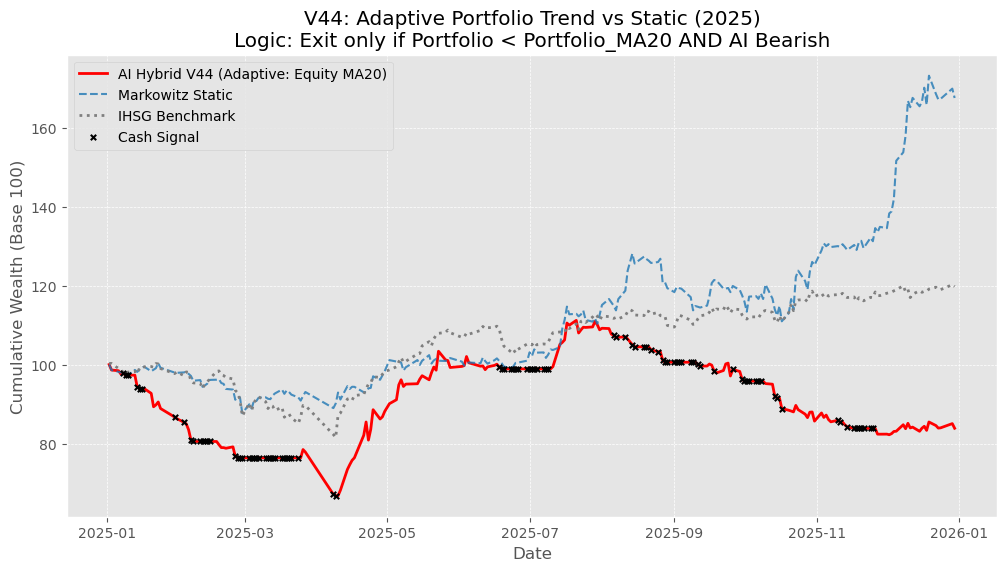

Total Days in Cash: 94


In [5]:
# --- Visualization: Performance Comparison ---
plt.figure(figsize=(12, 6))
plt.plot(hybrid_res_v44_adaptive['Portfolio_Value'], label=f'AI Hybrid V44 (Adaptive: Equity MA20)', color='red', linewidth=2)
plt.plot(static_res['Portfolio_Value'], label='Markowitz Static', color='#1f77b4', linestyle='--', alpha=0.8)
plt.plot(ihsg_price, label='IHSG Benchmark', color='#7f7f7f', linestyle=':', linewidth=2)

# Highlight Cash Days
regime_switches = hybrid_res_v44_adaptive[hybrid_res_v44_adaptive['State'].str.contains('Cash')]
if not regime_switches.empty:
    plt.scatter(regime_switches.index, regime_switches['Portfolio_Value'], color='black', s=15, marker='x', label='Cash Signal', zorder=5)

plt.title(f'V44: Adaptive Portfolio Trend vs Static (2025)\nLogic: Exit only if Portfolio < Portfolio_MA20 AND AI Bearish')
plt.ylabel('Cumulative Wealth (Base 100)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig('v44_adaptive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Stats
cash_days = hybrid_res_v44_adaptive['State'].value_counts().get('Cash', 0)
print(f"Total Days in Cash: {cash_days}")
